# Módulo 4, Parte 1. Asociación, predicción lineal y cautela causal en investigación social aplicada

**Curso:** Fundamentos de Programación para IA Generativa Aplicada  
**Orientación:** Ciencias sociales aplicadas  
**Sesión:** 4, Parte 1

---

## Propósito de esta parte

En esta sesión distinguiremos con rigor cuatro niveles analíticos que suelen confundirse:

1. **descripción**;
2. **asociación**;
3. **predicción**;
4. **causalidad**.

Trabajaremos sobre la base real construida en la sesión 2 y usaremos una simulación breve solo como apoyo pedagógico para entender el sesgo por variable omitida.

---

## Idea central

Un modelo estadístico no reemplaza a la teoría.

- La **descripción** organiza patrones observables.
- La **asociación** cuantifica covariaciones.
- La **predicción** optimiza desempeño fuera de muestra.
- La **causalidad** exige supuestos y diseño de identificación.

En términos simples: que un modelo ajuste bien no significa que haya identificado un mecanismo causal.

## 1. Marco conceptual mínimo

### 1.1 Cuatro preguntas distintas

| Pregunta | Nivel analítico | Qué buscamos |
|---|---|---|
| ¿Cómo se distribuye el ingreso del hogar? | Descripción | Resumir estructura observable |
| ¿Se asocia el ingreso con educación o NBI? | Asociación | Medir covariación |
| ¿Qué valor de ingreso predecimos para un hogar nuevo? | Predicción | Minimizar error fuera de muestra |
| ¿Qué efecto tendría cambiar X sobre Y? | Causalidad | Identificar un mecanismo contrafactual |

### 1.2 Regla metodológica

No toda regresión es causal. Una regresión lineal puede servir para:
- describir;
- resumir asociación;
- predecir;
- o, bajo supuestos adicionales fuertes, aproximar un efecto causal.

Pero la librería o el modelo no “vuelven causal” una estimación por sí mismos.

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf
import statsmodels.api as sm

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context="talk")
np.random.seed(42)

In [3]:
# Rutas de trabajo

RUTA_RESULTADOS_S2 = Path("/content/drive/MyDrive/IA Generativa para CCSS/Base de datos/Resultados/Sesión 2")
RUTA_RESULTADOS_S4 = Path("/content/drive/MyDrive/IA Generativa para CCSS/Base de datos/Resultados/Sesión 4")

RUTA_RESULTADOS_S4.mkdir(parents=True, exist_ok=True)

if not RUTA_RESULTADOS_S2.exists():
    raise FileNotFoundError(
        f"No se encontró la carpeta de resultados de la sesión 2:\n{RUTA_RESULTADOS_S2}"
    )

print("Lectura desde :", RUTA_RESULTADOS_S2)
print("Exportación a :", RUTA_RESULTADOS_S4)

Lectura desde : /content/drive/MyDrive/IA Generativa para CCSS/Base de datos/Resultados/Sesión 2
Exportación a : /content/drive/MyDrive/IA Generativa para CCSS/Base de datos/Resultados/Sesión 4


In [4]:
# Archivos esperados

ARCHIVO_HOGAR = RUTA_RESULTADOS_S2 / "enaho_hogar_panel_2021_2024.csv"
ARCHIVO_DPTO  = RUTA_RESULTADOS_S2 / "base_final_2021_2024_pib.csv"

for ruta in [ARCHIVO_HOGAR, ARCHIVO_DPTO]:
    if not ruta.exists():
        raise FileNotFoundError(f"No se encontró el archivo esperado:\n{ruta}")

enaho_hogar_panel = pd.read_csv(ARCHIVO_HOGAR)
base_final = pd.read_csv(ARCHIVO_DPTO)

print("Dimensiones cargadas:")
print("enaho_hogar_panel:", enaho_hogar_panel.shape)
print("base_final       :", base_final.shape)

Dimensiones cargadas:
enaho_hogar_panel: (176755, 24)
base_final       : (100, 16)


## 2. Unidad de observación y variable dependiente

En esta parte trabajaremos principalmente con la base **hogar × año**.

### Unidad de observación
Cada fila representa un **hogar** observado en un año.

### Variable dependiente
Usaremos como variable de resultado:

- `ln_ingreso_hogar`: logaritmo del ingreso total del hogar.

Esto tiene dos ventajas:
1. reduce asimetría;
2. permite una lectura porcentual aproximada de coeficientes en modelos log-nivel.

### Variables explicativas iniciales
Usaremos:

- `hogar_con_superior`: indicador de presencia de educación superior en el hogar;
- `hogar_participa`: indicador de participación organizativa del hogar;
- `n_nbi`: número de necesidades básicas insatisfechas;
- `anio`: para controlar variación temporal mínima.

In [5]:
# Preparación del dataset de modelización

cols_modelo = [
    "ln_ingreso_hogar",
    "ingreso_hogar_total",
    "hogar_con_superior",
    "hogar_participa",
    "n_nbi",
    "anio",
    "cod_dpto"
]

df_modelo = enaho_hogar_panel[cols_modelo].copy()

for col in cols_modelo:
    if col in df_modelo.columns:
        df_modelo[col] = pd.to_numeric(df_modelo[col], errors="coerce")

df_modelo["cod_dpto"] = df_modelo["cod_dpto"].astype("string").str.zfill(2)
df_modelo["anio"] = df_modelo["anio"].astype("Int64")

# Mantener solo observaciones utilizables para esta parte
df_modelo = df_modelo.dropna(subset=["ln_ingreso_hogar", "hogar_con_superior", "hogar_participa", "n_nbi", "anio"]).copy()

print("Base de modelización:")
print(df_modelo.shape)
display(df_modelo.head())

Base de modelización:
(75232, 7)


,ln_ingreso_hogar,ingreso_hogar_total,hogar_con_superior,hogar_participa,n_nbi,anio,cod_dpto
0,8.0605,"3,166.0000",0.0000,1.0000,0.0000,2021,01
1,9.2988,"10,924.2773",0.0000,0.0000,1.0000,2021,01
2,8.8543,"7,003.3125",1.0000,1.0000,0.0000,2021,01
4,10.4148,"33,347.4214",1.0000,0.0000,0.0000,2021,01
7,8.7383,"6,236.5190",1.0000,0.0000,0.0000,2021,01


In [6]:
# Auditoría mínima

resumen_missing = pd.DataFrame({
    "variable": df_modelo.columns,
    "n_missing": df_modelo.isna().sum().values,
    "pct_missing": (df_modelo.isna().mean() * 100).round(2).values,
    "dtype": df_modelo.dtypes.astype(str).values
})

display(resumen_missing)
print("\nAños disponibles:", sorted(df_modelo["anio"].dropna().unique().tolist()))
print("Departamentos   :", df_modelo["cod_dpto"].nunique())

,variable,n_missing,pct_missing,dtype
0,ln_ingreso_hogar,0,0.0000,float64
1,ingreso_hogar_total,0,0.0000,float64
2,hogar_con_superior,0,0.0000,float64
3,hogar_participa,0,0.0000,float64
4,n_nbi,0,0.0000,float64
5,anio,0,0.0000,Int64
6,cod_dpto,0,0.0000,string



Años disponibles: [2021, 2022, 2023, 2024]
Departamentos   : 25


## 3. Descripción antes del modelo

Antes de estimar una regresión, conviene describir mínimamente el objeto empírico. La modelización no debe reemplazar este paso. En ciencias sociales, una regresión sin descripción previa suele producir interpretaciones excesivas.



In [7]:
# Resumen descriptivo básico

tabla_desc = df_modelo[[
    "ln_ingreso_hogar",
    "ingreso_hogar_total",
    "hogar_con_superior",
    "hogar_participa",
    "n_nbi"
]].describe().T.round(4)

display(tabla_desc)

,count,mean,std,min,25%,50%,75%,max
ln_ingreso_hogar,"75,232.0000",9.7150,1.0375,4.7707,9.2351,9.8093,10.4010,13.2327
ingreso_hogar_total,"75,232.0000","25,795.5663","26,184.3174",117.0000,"10,250.0000","18,201.7344","32,892.7500","558,306.0000"
hogar_con_superior,"75,232.0000",0.5481,0.4977,0.0000,0.0000,1.0000,1.0000,1.0000
hogar_participa,"75,232.0000",0.4100,0.4918,0.0000,0.0000,0.0000,1.0000,1.0000
n_nbi,"75,232.0000",0.1809,0.4559,0.0000,0.0000,0.0000,0.0000,4.0000


In [8]:
# Comparación descriptiva por presencia de educación superior en el hogar

tabla_grupos = (
    df_modelo
    .groupby("hogar_con_superior", as_index=False)
    .agg(
        n_hogares=("ln_ingreso_hogar", "count"),
        ingreso_promedio=("ingreso_hogar_total", "mean"),
        ln_ingreso_promedio=("ln_ingreso_hogar", "mean"),
        nbi_promedio=("n_nbi", "mean"),
        pct_participa=("hogar_participa", "mean")
    )
    .round(4)
)

display(tabla_grupos)

,hogar_con_superior,n_hogares,ingreso_promedio,ln_ingreso_promedio,nbi_promedio,pct_participa
0,0.0000,33999,"14,683.4228",9.2173,0.2940,0.4856
1,1.0000,41233,"34,958.1731",10.1253,0.0877,0.3477


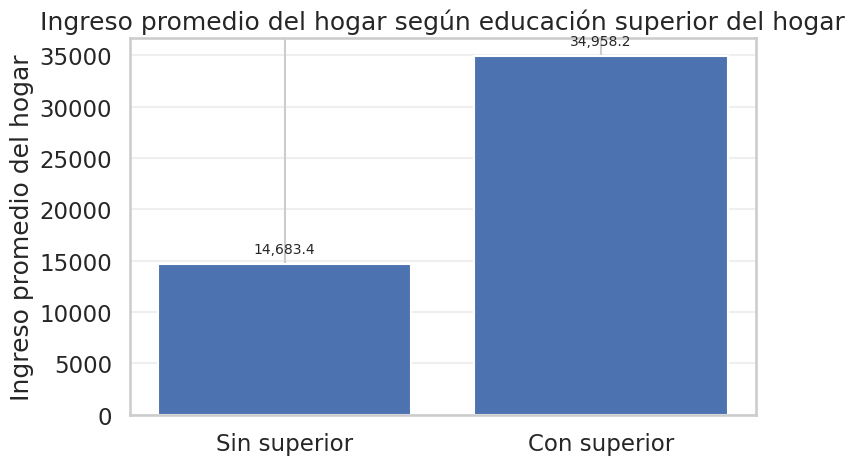

In [10]:
# Gráfico descriptivo simple: promedio de ingreso por grupo

plot_df = tabla_grupos.copy()
plot_df["grupo"] = plot_df["hogar_con_superior"].map({0.0: "Sin superior", 1.0: "Con superior"})

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(plot_df["grupo"], plot_df["ingreso_promedio"])
ax.set_title("Ingreso promedio del hogar según educación superior del hogar")
ax.set_xlabel("")
ax.set_ylabel("Ingreso promedio del hogar")
ax.grid(True, axis="y", alpha=0.3)

for x, y in zip(plot_df["grupo"], plot_df["ingreso_promedio"]):
    ax.annotate(f"{y:,.1f}", (x, y), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=10)

plt.tight_layout()
fig.savefig(RUTA_RESULTADOS_S4 / "01_ingreso_promedio_por_educ_superior.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Asociación lineal simple

Estimaremos primero un modelo lineal muy básico:

\[
\ln(\text{ingreso hogar}) = \beta_0 + \beta_1 \cdot \text{hogar\_con\_superior} + \varepsilon
\]

### Qué sí hace este modelo
Mide una **asociación promedio bruta** entre presencia de educación superior en el hogar e ingreso del hogar.

### Qué no hace este modelo
No identifica por sí mismo un efecto causal de la educación sobre el ingreso.

In [11]:
# Modelo lineal simple con errores robustos

m1 = smf.ols(
    "ln_ingreso_hogar ~ hogar_con_superior",
    data=df_modelo
).fit(cov_type="HC3")

print(m1.summary())

                            OLS Regression Results                            
Dep. Variable:       ln_ingreso_hogar   R-squared:                       0.190
Model:                            OLS   Adj. R-squared:                  0.190
Method:                 Least Squares   F-statistic:                 1.724e+04
Date:                Sat, 21 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:13:12   Log-Likelihood:            -1.0160e+05
No. Observations:               75232   AIC:                         2.032e+05
Df Residuals:                   75230   BIC:                         2.032e+05
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              9.2173      0

In [12]:
# Tabla corta de coeficientes del modelo simple

tabla_m1 = pd.DataFrame({
    "coef": m1.params,
    "se_robusto": m1.bse,
    "p_value": m1.pvalues,
    "ic_low": m1.conf_int()[0],
    "ic_high": m1.conf_int()[1]
}).round(4)

display(tabla_m1)

,coef,se_robusto,p_value,ic_low,ic_high
Intercept,9.2173,0.0054,0.0000,9.2068,9.2278
hogar_con_superior,0.9080,0.0069,0.0000,0.8945,0.9216


In [13]:
# Interpretación porcentual del coeficiente binario en log-nivel

beta_sup_m1 = m1.params["hogar_con_superior"]
efecto_pct_aprox = beta_sup_m1 * 100
efecto_pct_exacto = (np.exp(beta_sup_m1) - 1) * 100

print("Interpretación del modelo simple")
print("-" * 40)
print(f"Coeficiente (hogar_con_superior)          : {beta_sup_m1:.4f}")
print(f"Aprox. porcentual (β × 100)               : {efecto_pct_aprox:.2f}%")
print(f"Interpretación exacta ((e^β - 1) × 100)   : {efecto_pct_exacto:.2f}%")
print()
print("Lectura correcta:")
print("Los hogares con presencia de educación superior presentan, en promedio,")
print("un ingreso mayor que los hogares sin esa característica.")
print("Esto describe una asociación bruta; no demuestra causalidad.")

Interpretación del modelo simple
----------------------------------------
Coeficiente (hogar_con_superior)          : 0.9080
Aprox. porcentual (β × 100)               : 90.80%
Interpretación exacta ((e^β - 1) × 100)   : 147.95%

Lectura correcta:
Los hogares con presencia de educación superior presentan, en promedio,
un ingreso mayor que los hogares sin esa característica.
Esto describe una asociación bruta; no demuestra causalidad.


## 5. Modelo múltiple: asociación ajustada

Ahora agregamos controles observables mínimos:

\[
\ln(\text{ingreso hogar}) = \beta_0 + \beta_1 \cdot \text{hogar\_con\_superior} + \beta_2 \cdot \text{n\_nbi} + \beta_3 \cdot \text{hogar\_participa} + \gamma_t \cdot \text{año} + \varepsilon
\]

### Qué cambia al agregar controles
El coeficiente de `hogar_con_superior` deja de ser una asociación bruta y pasa a ser una **asociación condicional** dada la información observada incluida en el modelo.

### Qué sigue sin resolverse
Todavía pueden existir:
- variables omitidas;
- endogeneidad;
- simultaneidad;
- selección no observada.

In [15]:
# Modelo lineal múltiple con controles observables y efectos de año

# Convertir 'anio' a int estándar para evitar errores con patsy (usado por statsmodels)
df_modelo["anio"] = df_modelo["anio"].astype(int)

m2 = smf.ols(
    "ln_ingreso_hogar ~ hogar_con_superior + n_nbi + hogar_participa + C(anio)",
    data=df_modelo
).fit(cov_type="HC3")

print(m2.summary())

                            OLS Regression Results                            
Dep. Variable:       ln_ingreso_hogar   R-squared:                       0.207
Model:                            OLS   Adj. R-squared:                  0.207
Method:                 Least Squares   F-statistic:                     3156.
Date:                Sat, 21 Mar 2026   Prob (F-statistic):               0.00
Time:                        21:18:09   Log-Likelihood:            -1.0080e+05
No. Observations:               75232   AIC:                         2.016e+05
Df Residuals:                   75225   BIC:                         2.017e+05
Df Model:                           6                                         
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              9.2423      0

In [16]:
# Comparación entre modelo simple y múltiple

comparacion_betas = pd.DataFrame({
    "modelo": ["Simple", "Múltiple"],
    "beta_hogar_con_superior": [
        m1.params["hogar_con_superior"],
        m2.params["hogar_con_superior"]
    ],
    "r2": [m1.rsquared, m2.rsquared],
    "n_obs": [int(m1.nobs), int(m2.nobs)]
}).round(4)

display(comparacion_betas)

,modelo,beta_hogar_con_superior,r2,n_obs
0,Simple,0.9080,0.1897,75232
1,Múltiple,0.8475,0.2069,75232


In [17]:
# Tabla interpretable de coeficientes del modelo múltiple

tabla_m2 = pd.DataFrame({
    "coef": m2.params,
    "se_robusto": m2.bse,
    "p_value": m2.pvalues,
    "ic_low": m2.conf_int()[0],
    "ic_high": m2.conf_int()[1]
}).round(4)

display(tabla_m2)

tabla_m2.to_csv(RUTA_RESULTADOS_S4 / "tabla_coeficientes_modelo_multiple.csv", encoding="utf-8")
print("Tabla exportada: tabla_coeficientes_modelo_multiple.csv")

,coef,se_robusto,p_value,ic_low,ic_high
Intercept,9.2423,0.0086,0.0000,9.2254,9.2593
C(anio)[T.2022],0.0903,0.0097,0.0000,0.0713,0.1093
C(anio)[T.2023],0.1490,0.0097,0.0000,0.1299,0.1681
C(anio)[T.2024],0.1989,0.0096,0.0000,0.1801,0.2178
hogar_con_superior,0.8475,0.0070,0.0000,0.8338,0.8613
n_nbi,-0.1519,0.0080,0.0000,-0.1677,-0.1362
hogar_participa,-0.1844,0.0072,0.0000,-0.1984,-0.1703


Tabla exportada: tabla_coeficientes_modelo_multiple.csv


## 6. Por qué asociación ajustada no equivale a causalidad

Este es el punto decisivo de la sesión. Que el coeficiente cambie poco o mucho al agregar controles no resuelve, por sí mismo, el problema causal.

### Razones
1. Solo controlamos por variables **observadas**.
2. Puede haber factores no observados correlacionados con X e Y.
3. La direccionalidad del mecanismo puede no estar identificada.
4. El diseño sigue siendo observacional.

Por eso, en esta etapa, el lenguaje correcto es:
- **asociación bruta**;
- **asociación ajustada**;
- no todavía “efecto causal”.

In [18]:
# Simulación breve para ilustrar sesgo por variable omitida
# Aquí la simulación NO reemplaza a los datos reales.
# Solo sirve para mostrar cómo surge el sesgo cuando omitimos un confusor.

n = 5000
habilidad = np.random.normal(0, 1, n)
educ = np.clip(np.round(8 + 2.0 * habilidad + np.random.normal(0, 2, n)), 0, 18)
log_ing = 6.0 + 0.06 * educ + 0.50 * habilidad + np.random.normal(0, 0.4, n)

sim = pd.DataFrame({
    "log_ing": log_ing,
    "educ": educ,
    "habilidad": habilidad
})

m_bias = smf.ols("log_ing ~ educ", data=sim).fit()
m_true = smf.ols("log_ing ~ educ + habilidad", data=sim).fit()

tabla_bias = pd.DataFrame({
    "modelo": ["Sin habilidad observada", "Con habilidad observada"],
    "beta_educ": [m_bias.params["educ"], m_true.params["educ"]],
    "r2": [m_bias.rsquared, m_true.rsquared]
}).round(4)

display(tabla_bias)

,modelo,beta_educ,r2
0,Sin habilidad observada,0.1815,0.4805
1,Con habilidad observada,0.0590,0.7117


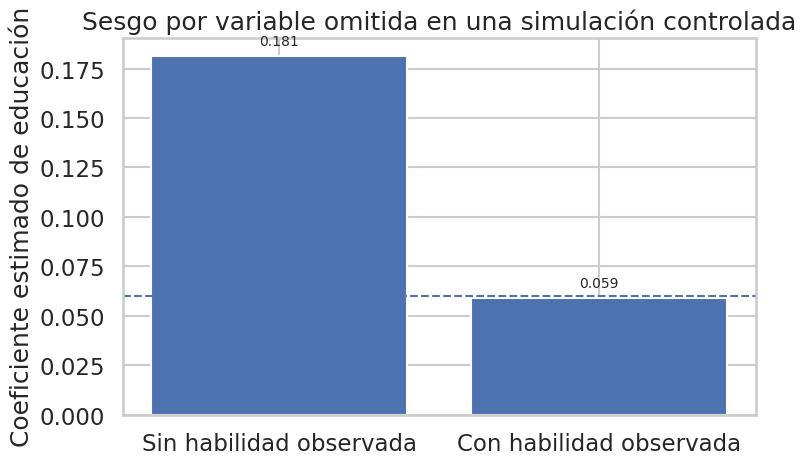

In [19]:
# Visualización del sesgo por variable omitida

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(tabla_bias["modelo"], tabla_bias["beta_educ"])
ax.axhline(0.06, linestyle="--", linewidth=1.5)
ax.set_title("Sesgo por variable omitida en una simulación controlada")
ax.set_xlabel("")
ax.set_ylabel("Coeficiente estimado de educación")

for x, y in zip(tabla_bias["modelo"], tabla_bias["beta_educ"]):
    ax.annotate(f"{y:.3f}", (x, y), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=10)

plt.tight_layout()
fig.savefig(RUTA_RESULTADOS_S4 / "02_sesgo_variable_omitida_simulacion.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Predicción lineal con `sklearn`

Hasta aquí usamos `statsmodels` para resumir asociaciones e inferencia. Ahora cambiamos de pregunta:

### Nueva pregunta
**¿Qué tan bien podemos predecir `ln_ingreso_hogar` para observaciones no vistas?**

Aquí ya no nos interesa principalmente:
- el p-value,
- ni el intervalo de confianza,
- ni la interpretación estructural fina del coeficiente.

Aquí interesa:
- desempeño fuera de muestra;
- error de predicción;
- estabilidad entre train y test.

In [20]:
# Construcción de matriz X para predicción

X_pred = df_modelo[["hogar_con_superior", "n_nbi", "hogar_participa", "anio"]].copy()
X_pred = pd.get_dummies(X_pred, columns=["anio"], drop_first=True, dtype=float)

y_pred = df_modelo["ln_ingreso_hogar"].astype(float)

print("Matriz de predicción:")
print("X:", X_pred.shape)
print("y:", y_pred.shape)

display(X_pred.head())

Matriz de predicción:
X: (75232, 6)
y: (75232,)


,hogar_con_superior,n_nbi,hogar_participa,anio_2022,anio_2023,anio_2024
0,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000
1,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000
2,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000
4,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000
7,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [21]:
# Split train/test

X_train, X_test, y_train, y_test = train_test_split(
    X_pred, y_pred, test_size=0.2, random_state=42
)

modelo_sk = LinearRegression()
modelo_sk.fit(X_train, y_train)

y_hat_train = modelo_sk.predict(X_train)
y_hat_test = modelo_sk.predict(X_test)

metricas_pred = pd.DataFrame({
    "muestra": ["train", "test"],
    "R2": [
        r2_score(y_train, y_hat_train),
        r2_score(y_test, y_hat_test)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_train, y_hat_train)),
        np.sqrt(mean_squared_error(y_test, y_hat_test))
    ],
    "MAE": [
        mean_absolute_error(y_train, y_hat_train),
        mean_absolute_error(y_test, y_hat_test)
    ]
}).round(4)

display(metricas_pred)

,muestra,R2,RMSE,MAE
0,train,0.2068,0.9243,0.7082
1,test,0.2074,0.9226,0.7089


In [22]:
# Coeficientes del modelo predictivo lineal

tabla_coef_sk = pd.DataFrame({
    "variable": X_pred.columns,
    "coeficiente": modelo_sk.coef_
}).round(4)

display(tabla_coef_sk)

,variable,coeficiente
0,hogar_con_superior,0.8488
1,n_nbi,-0.1518
2,hogar_participa,-0.1808
3,anio_2022,0.0912
4,anio_2023,0.1446
5,anio_2024,0.1986


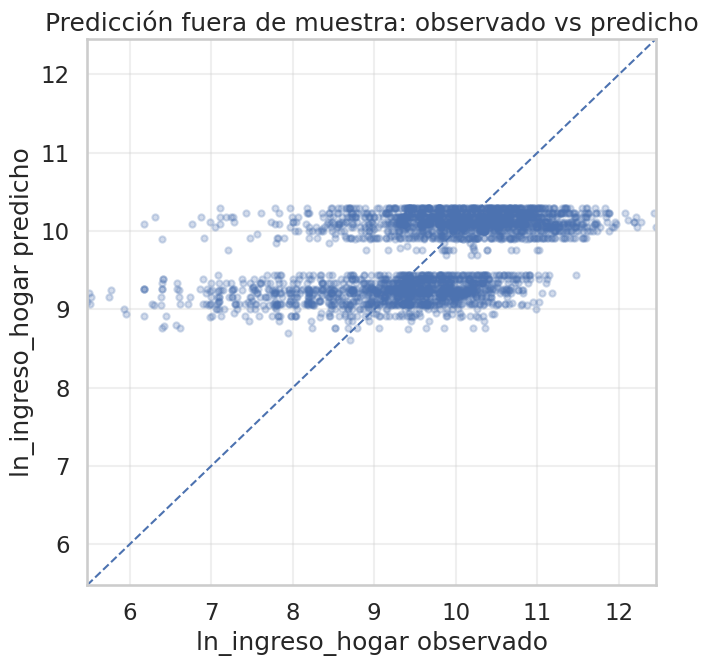

In [23]:
# Gráfico: observado vs predicho en test

plot_df = pd.DataFrame({
    "observado": y_test,
    "predicho": y_hat_test
}).copy()

if len(plot_df) > 3000:
    plot_df = plot_df.sample(3000, random_state=42)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(plot_df["observado"], plot_df["predicho"], alpha=0.25, s=20)
lims = [
    min(plot_df["observado"].min(), plot_df["predicho"].min()),
    max(plot_df["observado"].max(), plot_df["predicho"].max())
]
ax.plot(lims, lims, linestyle="--", linewidth=1.5)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_title("Predicción fuera de muestra: observado vs predicho")
ax.set_xlabel("ln_ingreso_hogar observado")
ax.set_ylabel("ln_ingreso_hogar predicho")
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(RUTA_RESULTADOS_S4 / "03_observado_vs_predicho_test.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. statsmodels vs sklearn: misma familia de modelo, preguntas distintas

Aquí ya puede verse una distinción muy importante.

### `statsmodels`
Se usa mejor cuando quieres:
- resumir coeficientes;
- evaluar significancia estadística;
- construir intervalos de confianza;
- discutir asociación bajo supuestos explícitos.

### `sklearn`
Se usa mejor cuando quieres:
- entrenar sobre una muestra;
- predecir en otra;
- comparar error fuera de muestra;
- extender el flujo hacia machine learning.

### Punto decisivo
El mismo tipo de modelo lineal puede servir para dos propósitos distintos, dependiendo de la pregunta.

In [24]:
# Exportar métricas y tablas

metricas_pred.to_csv(RUTA_RESULTADOS_S4 / "tabla_metricas_prediccion_lineal.csv", index=False, encoding="utf-8")
tabla_coef_sk.to_csv(RUTA_RESULTADOS_S4 / "tabla_coeficientes_sklearn_lineal.csv", index=False, encoding="utf-8")
comparacion_betas.to_csv(RUTA_RESULTADOS_S4 / "tabla_comparacion_modelo_simple_multiple.csv", index=False, encoding="utf-8")

print("Archivos exportados:")
print("- tabla_metricas_prediccion_lineal.csv")
print("- tabla_coeficientes_sklearn_lineal.csv")
print("- tabla_comparacion_modelo_simple_multiple.csv")

Archivos exportados:
- tabla_metricas_prediccion_lineal.csv
- tabla_coeficientes_sklearn_lineal.csv
- tabla_comparacion_modelo_simple_multiple.csv


## 9. Ejercicio aplicado

Con base en esta primera parte, responde:

1. ¿qué diferencia conceptual hay entre una asociación bruta y una asociación ajustada?
2. ¿por qué el coeficiente de `hogar_con_superior` no debe leerse automáticamente como efecto causal?
3. ¿qué problema ilustra la simulación con `habilidad`?
4. ¿qué cambia cuando pasamos de `statsmodels` a `sklearn`?
5. ¿qué te importa más en cada caso: interpretación o error fuera de muestra?

### Pregunta de articulación con la Tarea 1

Entre estas rutas, ¿cuál parece más prometedora para tu avance inicial?

- ingreso del hogar y educación superior;
- ingreso del hogar y NBI;
- participación del hogar e ingreso;
- evolución temporal 2021–2024 con comparación Cusco vs Perú.

## 10. Cierre de la Parte 1

En esta primera parte del módulo 4 hemos ordenado la transición desde la visualización hacia la modelización.

### Lo logrado
- distinguir descripción, asociación, predicción y causalidad;
- estimar modelos lineales simples y múltiples sobre una base real;
- interpretar coeficientes log-nivel con cuidado;
- mostrar por qué “más controles” no equivale automáticamente a causalidad;
- ilustrar el sesgo por variable omitida mediante una simulación breve;
- introducir el flujo predictivo con train/test usando `sklearn`.

### Regla metodológica consolidada

La secuencia correcta no es:

**regresión = causalidad**

sino:

**pregunta → estructura de datos → modelo adecuado → interpretación prudente → límites del diseño**

### Lo que seguirá en la Parte 2

Sobre este mismo Colab continuaremos con:
- regresión logística;
- clasificación;
- métricas para variables binarias;
- umbrales de decisión;
- y discusión más fina sobre diseño empírico para la Tarea 1.

# Módulo 4, Parte 2. Regresión logística, clasificación y umbrales de decisión en investigación social aplicada

**Curso:** Fundamentos de Programación para IA Generativa Aplicada  
**Orientación:** Ciencias sociales aplicadas  
**Sesión:** 4, Parte 2

---

## Propósito de esta parte

En esta sesión cerraremos el módulo 4 trabajando con una variable binaria real construida en la sesión 2.

El objetivo es distinguir con claridad entre:

1. **modelar una probabilidad**;
2. **clasificar observaciones**;
3. **evaluar desempeño predictivo**;
4. **y evitar errores de interpretación causal**.

Trabajaremos con la probabilidad de que un hogar sea pobre por NBI en el período 2021–2024.

---

## Idea central

En modelos binarios, la pregunta ya no es:

**¿cuánto cambia Y?**

sino:

**¿cómo cambia la probabilidad de que ocurra Y = 1?**

En esta lógica:

- la regresión logística modela probabilidades;
- la clasificación convierte probabilidades en decisiones mediante umbrales;
- el umbral no es neutro: cambia precisión, recall y tipo de error.

Un buen modelo clasificatorio no identifica por sí solo un efecto causal.

## 1. Marco conceptual mínimo

### 1.1 Cuatro niveles que no deben confundirse

- **descripción**: ¿qué proporción de hogares es pobre por NBI?
- **asociación probabilística**: ¿cómo cambia la probabilidad observada según ingreso, educación o participación?
- **clasificación**: ¿qué tan bien distinguimos hogares pobres y no pobres?
- **causalidad**: ¿qué pasaría con la pobreza si cambiara una variable bajo un diseño contrafactual válido?

### 1.2 Regla metodológica

La regresión logística puede servir para:

- describir asociaciones probabilísticas;
- producir probabilidades predichas;
- clasificar observaciones;
- pero no “vuelve causal” el análisis por sí misma.

### 1.3 Cuidado clave

No debemos usar como predictor una variable que construye directamente el resultado.

Por eso, si el resultado es `pobre_nbi`, **no debemos incluir `n_nbi` como regresor**.  
Eso sería fuga de información y volvería trivial el problema.

In [25]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

pd.set_option("display.max_columns", 140)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid", context="talk")
np.random.seed(42)

In [27]:
# Rutas de trabajo

RUTA_RESULTADOS_S2 = Path("/content/drive/MyDrive/IA Generativa para CCSS/Base de datos/Resultados/Sesión 2")
RUTA_RESULTADOS_S4 = Path("/content/drive/MyDrive/IA Generativa para CCSS/Base de datos/Resultados/Sesión 4")

RUTA_RESULTADOS_S4.mkdir(parents=True, exist_ok=True)

if not RUTA_RESULTADOS_S2.exists():
    raise FileNotFoundError(
        f"No se encontró la carpeta de resultados de la sesión 2:\n{RUTA_RESULTADOS_S2}"
    )

print("Lectura desde :", RUTA_RESULTADOS_S2)
print("Exportación a :", RUTA_RESULTADOS_S4)

Lectura desde : /content/drive/MyDrive/IA Generativa para CCSS/Base de datos/Resultados/Sesión 2
Exportación a : /content/drive/MyDrive/IA Generativa para CCSS/Base de datos/Resultados/Sesión 4


In [28]:
# Archivos esperados

ARCHIVO_HOGAR = RUTA_RESULTADOS_S2 / "enaho_hogar_panel_2021_2024.csv"
ARCHIVO_FINAL = RUTA_RESULTADOS_S2 / "base_final_2021_2024_pib.csv"
ARCHIVO_CUSCO = RUTA_RESULTADOS_S2 / "base_cusco_2021_2024.csv"

for ruta in [ARCHIVO_HOGAR, ARCHIVO_FINAL, ARCHIVO_CUSCO]:
    if not ruta.exists():
        raise FileNotFoundError(f"No se encontró el archivo esperado:\n{ruta}")

enaho_hogar_panel = pd.read_csv(ARCHIVO_HOGAR)
base_final = pd.read_csv(ARCHIVO_FINAL)
base_cusco = pd.read_csv(ARCHIVO_CUSCO)

print("Dimensiones cargadas:")
print("enaho_hogar_panel:", enaho_hogar_panel.shape)
print("base_final       :", base_final.shape)
print("base_cusco       :", base_cusco.shape)

Dimensiones cargadas:
enaho_hogar_panel: (176755, 24)
base_final       : (100, 16)
base_cusco       : (4, 16)


## 2. Preparación de la base de clasificación

Trabajaremos a nivel **hogar × año**.

### Variable resultado
- `pobre_nbi` = 1 si el hogar presenta al menos una necesidad básica insatisfecha;
- `pobre_nbi` = 0 en caso contrario.

### Predictores principales
- `ln_ingreso_hogar`
- `hogar_con_superior`
- `hogar_participa`
- `n_org_hogar`
- `pib`
- `pib_crecimiento`
- `anio`

### Punto importante
No incluiremos `n_nbi`, porque `pobre_nbi` se deriva directamente de esa variable.

In [29]:
# Preparar llaves para merge con contexto departamental

enaho_hogar_panel["cod_dpto"] = enaho_hogar_panel["cod_dpto"].astype("string").str.zfill(2)
enaho_hogar_panel["anio"] = pd.to_numeric(enaho_hogar_panel["anio"], errors="coerce").astype("Int64")

base_final["cod_dpto"] = base_final["cod_dpto"].astype("string").str.zfill(2)
base_final["anio"] = pd.to_numeric(base_final["anio"], errors="coerce").astype("Int64")

# Traer contexto macro y nombre departamental
cols_contexto = ["cod_dpto", "anio", "departamento", "pib", "pib_crecimiento"]

df = enaho_hogar_panel.merge(
    base_final[cols_contexto].drop_duplicates(),
    on=["cod_dpto", "anio"],
    how="left",
    validate="m:1"
)

print("Base hogar × año con contexto:")
print(df.shape)
display(df.head())

Base hogar × año con contexto:
(176755, 27)


,UBIGEO,CONGLOME,VIVIENDA,HOGAR,cod_dpto,NBI1,NBI2,NBI3,NBI4,NBI5,n_nbi,pobre_nbi,n_registros_ingreso,ingreso_principal_total,ingreso_secundario_total,ingreso_hogar_total,hogar_con_superior,hogar_con_universitaria,max_nivel_educ,ln_ingreso_hogar,n_org_hogar,hogar_participa,tasa_participacion_obs,anio,departamento,pib,pib_crecimiento
0,10101,10400,15,11,01,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,NaN,"3,166.0000","3,166.0000",0.0000,0.0000,6.0000,8.0605,3.0000,1.0000,1.0000,2021,Amazonas,"3,122,772.0000",NaN
1,10101,10400,22,11,01,0.0000,1.0000,0.0000,0.0000,0.0000,1.0000,1.0000,3.0000,"10,924.2773",NaN,"10,924.2773",0.0000,0.0000,6.0000,9.2988,0.0000,0.0000,0.0000,2021,Amazonas,"3,122,772.0000",NaN
2,10101,10400,34,11,01,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,"7,003.3125",NaN,"7,003.3125",1.0000,1.0000,10.0000,8.8543,2.0000,1.0000,1.0000,2021,Amazonas,"3,122,772.0000",NaN
3,10101,10400,39,11,01,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,NaN,NaN,NaN,0.0000,0.0000,5.0000,NaN,0.0000,0.0000,0.0000,2021,Amazonas,"3,122,772.0000",NaN
4,10101,10400,51,11,01,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,4.0000,"33,347.4214",NaN,"33,347.4214",1.0000,0.0000,8.0000,10.4148,0.0000,0.0000,0.0000,2021,Amazonas,"3,122,772.0000",NaN


In [30]:
# Selección y tipificación de variables

cols_modelo = [
    "pobre_nbi",
    "ln_ingreso_hogar",
    "ingreso_hogar_total",
    "hogar_con_superior",
    "hogar_con_universitaria",
    "hogar_participa",
    "n_org_hogar",
    "pib",
    "pib_crecimiento",
    "anio",
    "cod_dpto",
    "departamento"
]

df_modelo = df[cols_modelo].copy()

for col in [
    "pobre_nbi",
    "ln_ingreso_hogar",
    "ingreso_hogar_total",
    "hogar_con_superior",
    "hogar_con_universitaria",
    "hogar_participa",
    "n_org_hogar",
    "pib",
    "pib_crecimiento",
    "anio"
]:
    if col in df_modelo.columns:
        df_modelo[col] = pd.to_numeric(df_modelo[col], errors="coerce")

df_modelo["cod_dpto"] = df_modelo["cod_dpto"].astype("string").str.zfill(2)
df_modelo["departamento"] = df_modelo["departamento"].astype("string")

# Mantener muestra usable para clasificación
df_modelo = df_modelo.dropna(subset=[
    "pobre_nbi",
    "ln_ingreso_hogar",
    "hogar_con_superior",
    "hogar_participa",
    "n_org_hogar",
    "pib_crecimiento",
    "anio"
]).copy()

df_modelo["pobre_nbi"] = df_modelo["pobre_nbi"].astype(int)

print("Base final de modelización:")
print(df_modelo.shape)
display(df_modelo.head())

Base final de modelización:
(53847, 12)


,pobre_nbi,ln_ingreso_hogar,ingreso_hogar_total,hogar_con_superior,hogar_con_universitaria,hogar_participa,n_org_hogar,pib,pib_crecimiento,anio,cod_dpto,departamento
43524,0,8.9962,"8,071.0000",0.0000,0.0000,1.0000,1.0000,"3,064,074.0000",-1.8797,2022,01,Amazonas
43528,0,9.5645,"14,249.0000",0.0000,0.0000,1.0000,2.0000,"3,064,074.0000",-1.8797,2022,01,Amazonas
43531,0,9.8445,"18,853.0000",0.0000,0.0000,1.0000,1.0000,"3,064,074.0000",-1.8797,2022,01,Amazonas
43535,0,10.3225,"30,408.0000",1.0000,1.0000,1.0000,1.0000,"3,064,074.0000",-1.8797,2022,01,Amazonas
43536,0,9.6605,"15,684.0000",0.0000,0.0000,0.0000,0.0000,"3,064,074.0000",-1.8797,2022,01,Amazonas


In [31]:
# Auditoría mínima

resumen = pd.DataFrame({
    "variable": df_modelo.columns,
    "n_missing": df_modelo.isna().sum().values,
    "pct_missing": (df_modelo.isna().mean() * 100).round(2).values,
    "dtype": df_modelo.dtypes.astype(str).values
})

display(resumen)

print("Años disponibles       :", sorted(df_modelo["anio"].dropna().unique().tolist()))
print("Departamentos          :", df_modelo["cod_dpto"].nunique())
print("Prevalencia pobre_nbi  :", round(df_modelo["pobre_nbi"].mean(), 4))

,variable,n_missing,pct_missing,dtype
0,pobre_nbi,0,0.0000,int64
1,ln_ingreso_hogar,0,0.0000,float64
2,ingreso_hogar_total,0,0.0000,float64
3,hogar_con_superior,0,0.0000,float64
4,hogar_con_universitaria,0,0.0000,float64
5,hogar_participa,0,0.0000,float64
6,n_org_hogar,0,0.0000,float64
7,pib,0,0.0000,float64
8,pib_crecimiento,0,0.0000,float64
9,anio,0,0.0000,Int64


Años disponibles       : [2022, 2023, 2024]
Departamentos          : 25
Prevalencia pobre_nbi  : 0.1615


## 3. Descripción del desenlace binario

Antes del modelo, conviene mirar tres cosas:

1. prevalencia total del desenlace;
2. variación temporal;
3. comparación simple entre Cusco y el total.

Eso ayuda a no tratar el problema como puramente algorítmico.

In [32]:
# Prevalencia general y por año

tabla_prev = (
    df_modelo
    .groupby("anio", as_index=False)
    .agg(
        n_hogares=("pobre_nbi", "count"),
        pct_pobre_nbi=("pobre_nbi", "mean")
    )
)

tabla_prev["pct_pobre_nbi_100"] = tabla_prev["pct_pobre_nbi"] * 100
display(tabla_prev.round(3))

,anio,n_hogares,pct_pobre_nbi,pct_pobre_nbi_100
0,2022,18411,0.1620,16.1640
1,2023,17912,0.1630,16.2910
2,2024,17524,0.1600,15.9780


In [33]:
# Comparación Cusco vs total Perú

tabla_cusco_peru = pd.DataFrame({
    "grupo": ["Perú", "Cusco"],
    "n_hogares": [
        len(df_modelo),
        int((df_modelo["cod_dpto"] == "08").sum())
    ],
    "pct_pobre_nbi": [
        df_modelo["pobre_nbi"].mean(),
        df_modelo.loc[df_modelo["cod_dpto"] == "08", "pobre_nbi"].mean()
    ]
})

tabla_cusco_peru["pct_pobre_nbi_100"] = tabla_cusco_peru["pct_pobre_nbi"] * 100
display(tabla_cusco_peru.round(3))

,grupo,n_hogares,pct_pobre_nbi,pct_pobre_nbi_100
0,Perú,53847,0.1610,16.1460
1,Cusco,1825,0.1120,11.2330


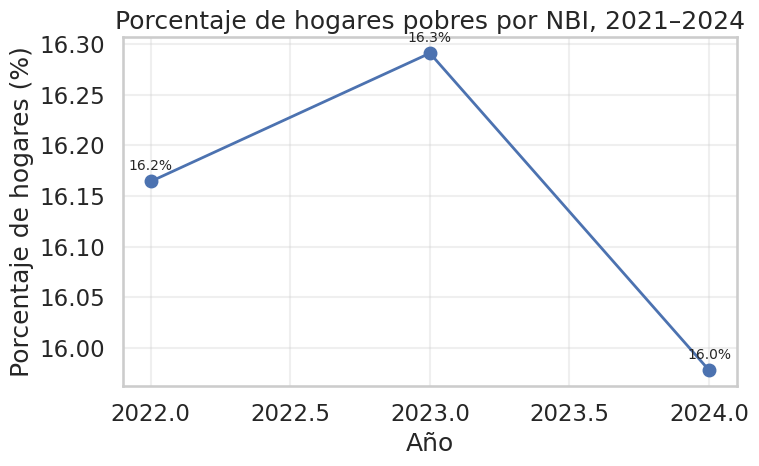

In [34]:
# Gráfico descriptivo: prevalencia por año

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(tabla_prev["anio"], tabla_prev["pct_pobre_nbi_100"], marker="o", linewidth=2)
ax.set_title("Porcentaje de hogares pobres por NBI, 2021–2024")
ax.set_xlabel("Año")
ax.set_ylabel("Porcentaje de hogares (%)")
ax.grid(True, alpha=0.3)

for x, y in zip(tabla_prev["anio"], tabla_prev["pct_pobre_nbi_100"]):
    ax.annotate(f"{y:.1f}%", (x, y), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=10)

plt.tight_layout()
fig.savefig(RUTA_RESULTADOS_S4 / "04_prevalencia_pobre_nbi_2021_2024.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Modelo logístico: asociación probabilística

Estimaremos primero un modelo logístico interpretable con `statsmodels`.

La ecuación será:

\[
\Pr(pobre\_nbi = 1) = f(\text{ingreso}, \text{educación}, \text{participación}, \text{contexto macro}, \text{año})
\]

### Qué sí hace este modelo
Resume cómo cambia la probabilidad observada del desenlace en función de covariables.

### Qué no hace por sí solo
No identifica un efecto causal sobre la pobreza.

In [36]:
# Modelo logístico con GLM binomial
# Usamos GLM Binomial porque es estable y permite interpretación clara.

formula_logit = (
    "pobre_nbi ~ ln_ingreso_hogar + hogar_con_superior + hogar_participa "
    "+ n_org_hogar + pib_crecimiento + C(anio)"
)

# Convertir 'anio' a int estándar para evitar errores con patsy (usado por statsmodels)
df_modelo["anio"] = df_modelo["anio"].astype(int)

m_logit = smf.glm(
    formula=formula_logit,
    data=df_modelo,
    family=sm.families.Binomial()
).fit(cov_type="HC3")

print(m_logit.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              pobre_nbi   No. Observations:                53847
Model:                            GLM   Df Residuals:                    53839
Model Family:                Binomial   Df Model:                            7
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -22134.
Date:                Sat, 21 Mar 2026   Deviance:                       44269.
Time:                        21:54:06   Pearson chi2:                 5.29e+04
No. Iterations:                     5   Pseudo R-squ. (CS):            0.06015
Covariance Type:                  HC3                                         
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              0.4614      0

In [37]:
# Coeficientes y odds ratios

tabla_logit = pd.DataFrame({
    "coef_logit": m_logit.params,
    "se_robusto": m_logit.bse,
    "p_value": m_logit.pvalues,
    "ic_low": m_logit.conf_int()[0],
    "ic_high": m_logit.conf_int()[1]
})

tabla_or = tabla_logit.copy()
for col in ["coef_logit", "ic_low", "ic_high"]:
    tabla_or[col] = np.exp(tabla_or[col])

tabla_or = tabla_or.rename(columns={
    "coef_logit": "odds_ratio",
    "ic_low": "or_ic_low",
    "ic_high": "or_ic_high"
}).round(4)

display(tabla_or)

,odds_ratio,se_robusto,p_value,or_ic_low,or_ic_high
Intercept,1.5863,0.1124,0.0000,1.2728,1.9771
C(anio)[T.2023],1.0230,0.0299,0.4474,0.9647,1.0847
C(anio)[T.2024],1.0096,0.0301,0.7508,0.9517,1.0711
ln_ingreso_hogar,0.8225,0.0119,0.0000,0.8035,0.8419
hogar_con_superior,0.3549,0.0286,0.0000,0.3356,0.3754
hogar_participa,1.2041,0.0401,0.0000,1.1132,1.3025
n_org_hogar,1.1607,0.0222,0.0000,1.1112,1.2124
pib_crecimiento,1.0024,0.0030,0.4109,0.9966,1.0083


In [38]:
# Interpretación rápida de odds ratios seleccionados

for var in ["ln_ingreso_hogar", "hogar_con_superior", "hogar_participa", "n_org_hogar", "pib_crecimiento"]:
    if var in tabla_or.index:
        print(f"{var}: OR = {tabla_or.loc[var, 'odds_ratio']:.4f}")

ln_ingreso_hogar: OR = 0.8225
hogar_con_superior: OR = 0.3549
hogar_participa: OR = 1.2041
n_org_hogar: OR = 1.1607
pib_crecimiento: OR = 1.0024


## 5. Efectos marginales: leer probabilidades, no solo odds ratios

Los odds ratios son útiles, pero no siempre intuitivos. Por eso conviene complementar con efectos marginales promedio, que aproximan cómo cambia la probabilidad esperada del evento ante cambios en los regresores.

In [39]:
# Efectos marginales promedio

margins = m_logit.get_margeff(at="overall")
print(margins.summary())

         GLM Marginal Effects        
Dep. Variable:              pobre_nbi
Method:                          dydx
At:                           overall
                        dy/dx    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
C(anio)[T.2023]        0.0029      0.004      0.760      0.447      -0.005       0.010
C(anio)[T.2024]        0.0012      0.004      0.318      0.751      -0.006       0.009
ln_ingreso_hogar      -0.0248      0.002    -16.390      0.000      -0.028      -0.022
hogar_con_superior    -0.1313      0.004    -36.617      0.000      -0.138      -0.124
hogar_participa        0.0235      0.005      4.638      0.000       0.014       0.033
n_org_hogar            0.0189      0.003      6.706      0.000       0.013       0.024
pib_crecimiento        0.0003      0.000      0.822      0.411      -0.000       0.001


In [40]:
# Probabilidades predichas en la base completa

df_modelo["prob_pred_statsmodels"] = m_logit.predict(df_modelo)

display(
    df_modelo[[
        "pobre_nbi",
        "prob_pred_statsmodels",
        "ln_ingreso_hogar",
        "hogar_con_superior",
        "hogar_participa",
        "n_org_hogar",
        "anio",
        "departamento"
    ]].head()
)

,pobre_nbi,prob_pred_statsmodels,ln_ingreso_hogar,hogar_con_superior,hogar_participa,n_org_hogar,anio,departamento
43524,0,0.2755,8.9962,0.0000,1.0000,1.0000,2022,Amazonas
43528,0,0.2832,9.5645,0.0000,1.0000,2.0000,2022,Amazonas
43531,0,0.2437,9.8445,0.0000,1.0000,1.0000,2022,Amazonas
43535,0,0.0943,10.3225,1.0000,1.0000,1.0000,2022,Amazonas
43536,0,0.1929,9.6605,0.0000,0.0000,0.0000,2022,Amazonas


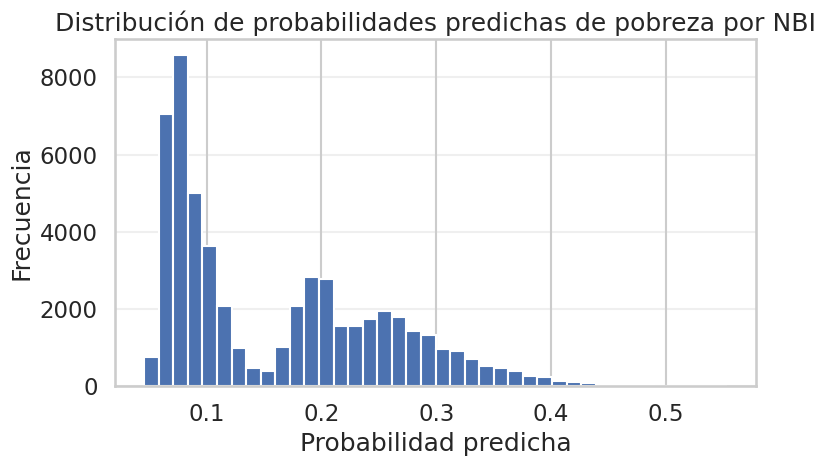

In [41]:
# Distribución de probabilidades predichas

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df_modelo["prob_pred_statsmodels"], bins=40, edgecolor="white")
ax.set_title("Distribución de probabilidades predichas de pobreza por NBI")
ax.set_xlabel("Probabilidad predicha")
ax.set_ylabel("Frecuencia")
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
fig.savefig(RUTA_RESULTADOS_S4 / "05_hist_probabilidades_predichas_logit.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Clasificación con `sklearn`

Ahora cambiamos de pregunta. Ya no preguntamos solo por asociación probabilística, sino por desempeño predictivo:

**¿qué tan bien clasificamos hogares pobres y no pobres fuera de muestra?**

Para ello usaremos:
- train/test split;
- regresión logística de `sklearn`;
- métricas de clasificación;
- umbrales alternativos.

In [42]:
# Matriz X y vector y para clasificación

X = df_modelo[[
    "ln_ingreso_hogar",
    "hogar_con_superior",
    "hogar_participa",
    "n_org_hogar",
    "pib_crecimiento",
    "anio"
]].copy()

X = pd.get_dummies(X, columns=["anio"], drop_first=True, dtype=float)
y = df_modelo["pobre_nbi"].astype(int)

print("Matriz X:", X.shape)
print("Vector y:", y.shape)
display(X.head())

Matriz X: (53847, 7)
Vector y: (53847,)


,ln_ingreso_hogar,hogar_con_superior,hogar_participa,n_org_hogar,pib_crecimiento,anio_2023,anio_2024
43524,8.9962,0.0000,1.0000,1.0000,-1.8797,0.0000,0.0000
43528,9.5645,0.0000,1.0000,2.0000,-1.8797,0.0000,0.0000
43531,9.8445,0.0000,1.0000,1.0000,-1.8797,0.0000,0.0000
43535,10.3225,1.0000,1.0000,1.0000,-1.8797,0.0000,0.0000
43536,9.6605,0.0000,0.0000,0.0000,-1.8797,0.0000,0.0000


In [43]:
# Split estratificado

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)
print("Prevalencia train:", y_train.mean().round(4))
print("Prevalencia test :", y_test.mean().round(4))

Train: (43077, 7) (43077,)
Test : (10770, 7) (10770,)
Prevalencia train: 0.1615
Prevalencia test : 0.1615


In [44]:
# Modelo logístico de clasificación

clf = LogisticRegression(
    max_iter=2000,
    solver="lbfgs"
)

clf.fit(X_train, y_train)

prob_test = clf.predict_proba(X_test)[:, 1]
pred_test_05 = (prob_test >= 0.5).astype(int)

metricas_05 = pd.DataFrame({
    "umbral": [0.5],
    "accuracy": [accuracy_score(y_test, pred_test_05)],
    "precision": [precision_score(y_test, pred_test_05, zero_division=0)],
    "recall": [recall_score(y_test, pred_test_05, zero_division=0)],
    "f1": [f1_score(y_test, pred_test_05, zero_division=0)],
    "roc_auc": [roc_auc_score(y_test, prob_test)]
}).round(4)

display(metricas_05)

,umbral,accuracy,precision,recall,f1,roc_auc
0,0.5000,0.8384,0.0000,0.0000,0.0000,0.6950


In [45]:
# Reporte de clasificación

print(classification_report(y_test, pred_test_05, digits=4, zero_division=0))

              precision    recall  f1-score   support

           0     0.8385    0.9999    0.9121      9031
           1     0.0000    0.0000    0.0000      1739

    accuracy                         0.8384     10770
   macro avg     0.4193    0.4999    0.4561     10770
weighted avg     0.7031    0.8384    0.7648     10770



In [46]:
# Matriz de confusión

cm = confusion_matrix(y_test, pred_test_05)

cm_df = pd.DataFrame(
    cm,
    index=["Real: no pobre", "Real: pobre"],
    columns=["Pred: no pobre", "Pred: pobre"]
)

display(cm_df)

,Pred: no pobre,Pred: pobre
Real: no pobre,9030,1
Real: pobre,1739,0


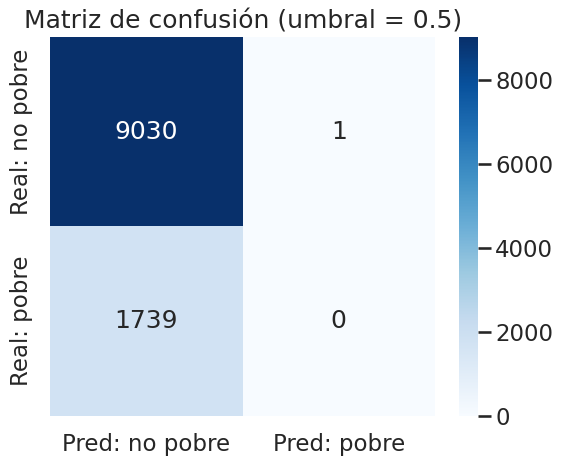

In [47]:
# Visualización de matriz de confusión

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title("Matriz de confusión (umbral = 0.5)")
plt.tight_layout()
fig.savefig(RUTA_RESULTADOS_S4 / "06_matriz_confusion_umbral_05.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Umbrales de decisión

La clasificación no depende solo del modelo, sino también del umbral.

Un umbral más bajo suele:
- aumentar recall;
- reducir precision.

Un umbral más alto suele:
- aumentar precision;
- reducir recall.

Por eso conviene comparar varios umbrales.

In [48]:
# Comparar métricas con varios umbrales

def evaluar_umbral(y_true, prob, threshold):
    pred = (prob >= threshold).astype(int)
    return {
        "umbral": threshold,
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1": f1_score(y_true, pred, zero_division=0)
    }

tabla_umbral = pd.DataFrame([
    evaluar_umbral(y_test, prob_test, 0.30),
    evaluar_umbral(y_test, prob_test, 0.50),
    evaluar_umbral(y_test, prob_test, 0.70)
]).round(4)

display(tabla_umbral)

,umbral,accuracy,precision,recall,f1
0,0.3000,0.8095,0.3286,0.1725,0.2262
1,0.5000,0.8384,0.0000,0.0000,0.0000
2,0.7000,0.8385,0.0000,0.0000,0.0000


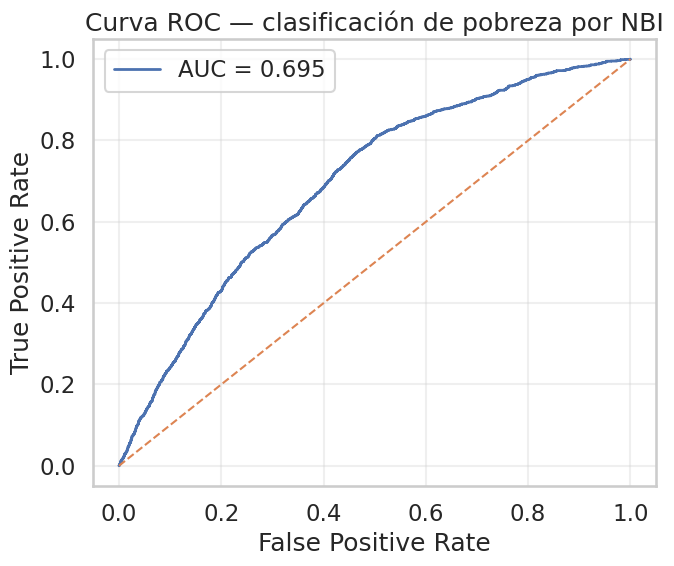

In [49]:
# Curva ROC

fpr, tpr, thresholds = roc_curve(y_test, prob_test)
auc = roc_auc_score(y_test, prob_test)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5)
ax.set_title("Curva ROC — clasificación de pobreza por NBI")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(frameon=True)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(RUTA_RESULTADOS_S4 / "07_curva_roc_pobre_nbi.png", dpi=300, bbox_inches="tight")
plt.show()

In [50]:
# Coeficientes del modelo sklearn

tabla_coef_clf = pd.DataFrame({
    "variable": X.columns,
    "coeficiente": clf.coef_[0]
}).sort_values("coeficiente", ascending=False).reset_index(drop=True)

display(tabla_coef_clf.round(4))

,variable,coeficiente
0,hogar_participa,0.1600
1,n_org_hogar,0.1492
2,anio_2023,0.0205
3,pib_crecimiento,0.0010
4,anio_2024,-0.0044
5,ln_ingreso_hogar,-0.1892
6,hogar_con_superior,-1.0551


## 8. Comparación breve: modelar probabilidad vs clasificar

Ya tenemos dos usos distintos de la regresión logística.

### `statsmodels`
Sirve mejor cuando quieres:
- interpretar coeficientes;
- calcular odds ratios;
- obtener efectos marginales;
- discutir asociación probabilística.

### `sklearn`
Sirve mejor cuando quieres:
- entrenar y evaluar fuera de muestra;
- clasificar;
- comparar métricas y umbrales;
- priorizar desempeño predictivo.

La familia del modelo puede ser la misma; la pregunta no lo es.

In [51]:
# Tabla resumen de métricas de clasificación

tabla_metricas_final = tabla_umbral.copy()
tabla_metricas_final["roc_auc"] = roc_auc_score(y_test, prob_test)

display(tabla_metricas_final.round(4))

,umbral,accuracy,precision,recall,f1,roc_auc
0,0.3000,0.8095,0.3286,0.1725,0.2262,0.6950
1,0.5000,0.8384,0.0000,0.0000,0.0000,0.6950
2,0.7000,0.8385,0.0000,0.0000,0.0000,0.6950


In [52]:
# Probabilidades predichas para toda la base y extracción de Cusco

X_full = pd.get_dummies(
    df_modelo[[
        "ln_ingreso_hogar",
        "hogar_con_superior",
        "hogar_participa",
        "n_org_hogar",
        "pib_crecimiento",
        "anio"
    ]].copy(),
    columns=["anio"],
    drop_first=True,
    dtype=float
)

# Alinear columnas por seguridad
for col in X.columns:
    if col not in X_full.columns:
        X_full[col] = 0.0
X_full = X_full[X.columns]

df_modelo["prob_pred_sklearn"] = clf.predict_proba(X_full)[:, 1]
df_modelo["pred_05"] = (df_modelo["prob_pred_sklearn"] >= 0.5).astype(int)

base_cusco_clf = df_modelo[df_modelo["cod_dpto"] == "08"].copy()
display(base_cusco_clf.head())

,pobre_nbi,ln_ingreso_hogar,ingreso_hogar_total,hogar_con_superior,hogar_con_universitaria,hogar_participa,n_org_hogar,pib,pib_crecimiento,anio,cod_dpto,departamento,prob_pred_statsmodels,prob_pred_sklearn,pred_05
54829,0,8.7519,"6,322.0000",1.0000,1.0000,0.0000,0.0000,"21,489,757.0000",4.3587,2022,08,Cusco,0.0933,0.0930,0
54831,0,10.2770,"29,055.0000",1.0000,1.0000,0.0000,0.0000,"21,489,757.0000",4.3587,2022,08,Cusco,0.0709,0.0714,0
54832,0,11.2991,"80,744.0000",1.0000,1.0000,0.0000,0.0000,"21,489,757.0000",4.3587,2022,08,Cusco,0.0588,0.0596,0
54833,1,9.1574,"9,483.0000",0.0000,0.0000,0.0000,0.0000,"21,489,757.0000",4.3587,2022,08,Cusco,0.2112,0.2143,0
54835,0,9.8165,"18,333.0000",1.0000,1.0000,0.0000,0.0000,"21,489,757.0000",4.3587,2022,08,Cusco,0.0771,0.0774,0


In [53]:
# Resumen Cusco 2021–2024: pobreza observada y probabilidad predicha media

tabla_cusco_clf = (
    base_cusco_clf
    .groupby("anio", as_index=False)
    .agg(
        n_hogares=("pobre_nbi", "count"),
        pct_pobre_obs=("pobre_nbi", "mean"),
        prob_media_pred=("prob_pred_sklearn", "mean")
    )
)

tabla_cusco_clf["pct_pobre_obs_100"] = tabla_cusco_clf["pct_pobre_obs"] * 100
tabla_cusco_clf["prob_media_pred_100"] = tabla_cusco_clf["prob_media_pred"] * 100

display(tabla_cusco_clf.round(3))

,anio,n_hogares,pct_pobre_obs,prob_media_pred,pct_pobre_obs_100,prob_media_pred_100
0,2022,608,0.1100,0.1770,11.0200,17.6730
1,2023,603,0.1190,0.1730,11.9400,17.2890
2,2024,614,0.1070,0.1650,10.7490,16.4880


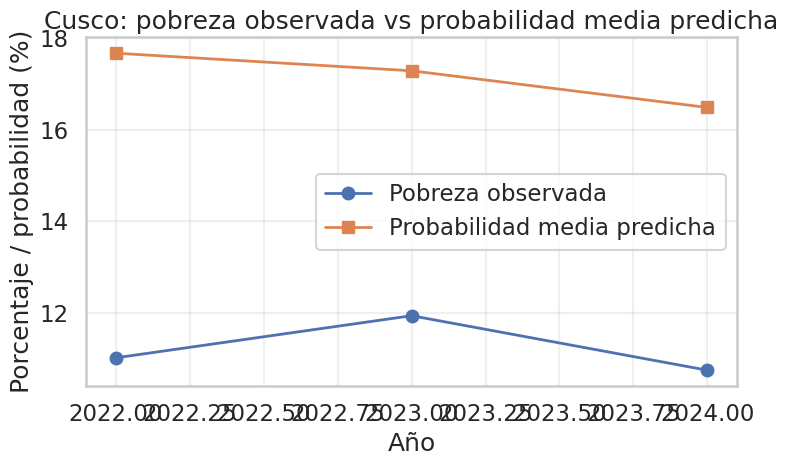

In [54]:
# Gráfico Cusco: observado vs probabilidad media predicha

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(tabla_cusco_clf["anio"], tabla_cusco_clf["pct_pobre_obs_100"], marker="o", linewidth=2, label="Pobreza observada")
ax.plot(tabla_cusco_clf["anio"], tabla_cusco_clf["prob_media_pred_100"], marker="s", linewidth=2, label="Probabilidad media predicha")

ax.set_title("Cusco: pobreza observada vs probabilidad media predicha")
ax.set_xlabel("Año")
ax.set_ylabel("Porcentaje / probabilidad (%)")
ax.legend(frameon=True)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(RUTA_RESULTADOS_S4 / "08_cusco_observado_vs_prob_predicha.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Lectura metodológica final

Esta parte deja tres lecciones importantes.

### 9.1 Sobre modelización
Un modelo logístico puede resumir asociaciones probabilísticas útiles, pero no identifica automáticamente un mecanismo causal.

### 9.2 Sobre clasificación
Una clasificación no se evalúa solo por accuracy.  
Dependiendo del objetivo, puede ser más importante:
- capturar la mayor cantidad de casos positivos;
- o evitar falsos positivos.

### 9.3 Sobre investigación social aplicada
La selección del desenlace, los predictores y el umbral debe responder a una pregunta sustantiva, no solo a conveniencia computacional.

In [55]:
# Exportar tablas principales

tabla_or.to_csv(RUTA_RESULTADOS_S4 / "tabla_odds_ratios_logit_pobre_nbi.csv", encoding="utf-8")
tabla_metricas_final.to_csv(RUTA_RESULTADOS_S4 / "tabla_metricas_clasificacion_pobre_nbi.csv", index=False, encoding="utf-8")
tabla_coef_clf.to_csv(RUTA_RESULTADOS_S4 / "tabla_coeficientes_logistic_regression_sklearn.csv", index=False, encoding="utf-8")
tabla_cusco_clf.to_csv(RUTA_RESULTADOS_S4 / "tabla_cusco_probabilidades_clasificacion.csv", index=False, encoding="utf-8")
base_cusco_clf.to_csv(RUTA_RESULTADOS_S4 / "base_cusco_clasificacion_s4.csv", index=False, encoding="utf-8")

print("Archivos exportados correctamente.")

Archivos exportados correctamente.


## 10. Ejercicio aplicado

Responde brevemente:

1. ¿qué diferencia conceptual hay entre odds ratio y probabilidad?
2. ¿por qué no debemos incluir `n_nbi` como predictor de `pobre_nbi`?
3. ¿qué cambia entre usar `statsmodels` y `sklearn` en esta sesión?
4. ¿qué ocurre cuando bajamos el umbral de 0.5 a 0.3?
5. ¿qué tipo de error te preocuparía más en una aplicación social: falsos positivos o falsos negativos? ¿por qué?

### Pregunta de articulación con la Tarea 1

A partir de esta sesión, ¿qué ruta te parece más sólida para tu avance?

- analizar pobreza por NBI como resultado, a partir de ingreso, educación y participación;
- estudiar ingresos y condiciones de vida como eje descriptivo principal;
- comparar Cusco con Perú en trayectorias 2021–2024;
- combinar visualización + modelo simple + discusión prudente de mecanismos.

## 11. Cierre del módulo 4

Con esta segunda parte queda cerrado el módulo 4.

### Lo logrado en el módulo completo

- distinguir descripción, asociación, predicción y causalidad;
- estimar modelos lineales sobre base real;
- introducir cautela causal y sesgo por variable omitida;
- modelar un desenlace binario con regresión logística;
- clasificar observaciones con train/test;
- comparar métricas y umbrales;
- producir insumos exportables para la Tarea 1.

### Regla metodológica consolidada

La secuencia correcta no es:

**modelo complejo = mejor explicación**

sino:

**pregunta sustantiva → unidad de observación → variable adecuada → modelo adecuado → interpretación prudente → límites del diseño**

### Resultado pedagógico

Ahora el curso ya tiene una trayectoria coherente:

**estructura de datos → transformación → visualización → asociación → predicción → clasificación**